# CMR Recall-Stage Internal Diagnostics

Retrieval-time traces and evidence-field diagnostics computed
from per-trial `trace_sims` and `item_evidence_diag`.

---

## Setup

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

from cmr.config import (
    N, BASE_PARAMS,
    B_rec_grid, gamma_fc_grid, eta_grid, B_encD_scale_grid,
    n_sims,
)
from cmr.sweep import sweep_one_param
from cmr.utils import _get_sweep_entry
from cmr.diagnostics_recall import (
    get_trace_sims, mean_curve_over_sims, mean_vector_over_sims,
)
from cmr.visualization import (
    make_sweep_colors, _add_colorbar,
    plot_cosine_similarity_sweep,
    plot_mean_evidence_by_pos,
    plot_item_evidence_asymmetry_paired, 
    line_with_colored_points
)

## Run all four sweeps

In [3]:
sweep_B_rec = sweep_one_param(
    param_name="B_rec",
    param_grid=B_rec_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  B_rec=0.2  done
  B_rec=0.4  done
  B_rec=0.6  done
  B_rec=0.8  done
  B_rec=1  done
  B_rec=1.2  done


In [4]:
sweep_gamma_fc = sweep_one_param(
    param_name="gamma_fc",
    param_grid=gamma_fc_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  gamma_fc=0.2  done
  gamma_fc=0.3  done
  gamma_fc=0.4  done
  gamma_fc=0.5  done
  gamma_fc=0.6  done
  gamma_fc=0.7  done
  gamma_fc=0.8  done


In [5]:
sweep_eta = sweep_one_param(
    param_name="eta",
    param_grid=eta_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  eta=0.1  done
  eta=0.2  done
  eta=0.3  done
  eta=0.4  done
  eta=0.5  done
  eta=0.6  done


In [6]:
sweep_B_enc_scale = sweep_one_param(
    param_name="B_encD_scale",
    param_grid=B_encD_scale_grid,
    base_params=BASE_PARAMS,
    n_sims=n_sims,
    collect_diagnostics=True,
    recency_k=3,
)

  B_encD_scale=0.2  done
  B_encD_scale=0.4  done
  B_encD_scale=0.6  done
  B_encD_scale=0.8  done
  B_encD_scale=1  done


---
## $B_{rec}$

### Radicand $\mathrm{rad}(t)$ across retrieval steps

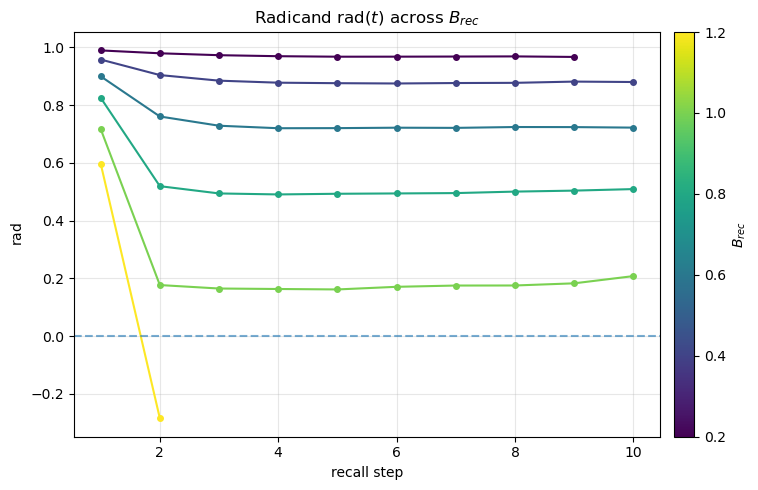

In [7]:
param_grid = np.asarray(B_rec_grid, dtype=float)
colors, norm, cmap = make_sweep_colors(param_grid)

fig, ax = plt.subplots(figsize=(8, 5))
for val, c in zip(param_grid, colors):
    ts = get_trace_sims(sweep_B_rec, val)
    x, rad = mean_curve_over_sims(ts, "rad")
    if x.size:
        ax.plot(x, rad, marker="o", color=c, ms=4)
ax.axhline(0, ls="--", alpha=0.6)
ax.set_title(r"Radicand $\mathrm{rad}(t)$ across $B_{rec}$")
ax.set_xlabel("recall step"); ax.set_ylabel(r"$\mathrm{rad}$")
ax.grid(alpha=0.3)
_add_colorbar(fig, ax, norm, cmap, r"$B_{rec}$")
fig.tight_layout(); plt.show()

### Cosine similarity $\cos(c, c_{in})$ after update

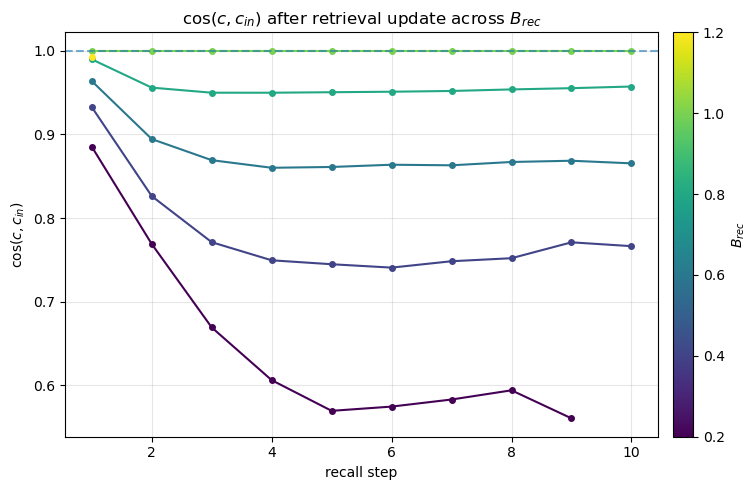

In [8]:
plot_cosine_similarity_sweep(sweep_B_rec, B_rec_grid, param_name=r"$B_{rec}$")

### Mean evidence $f_{in}(i)$ by serial position

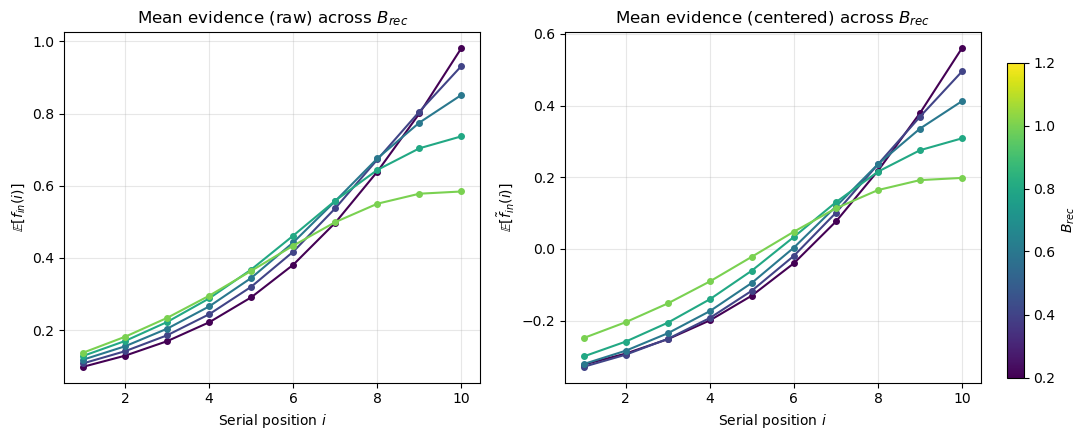

In [9]:
plot_mean_evidence_by_pos(sweep_B_rec, B_rec_grid, param_name=r"$B_{rec}$")

### Neighbor item-evidence asymmetry during selection

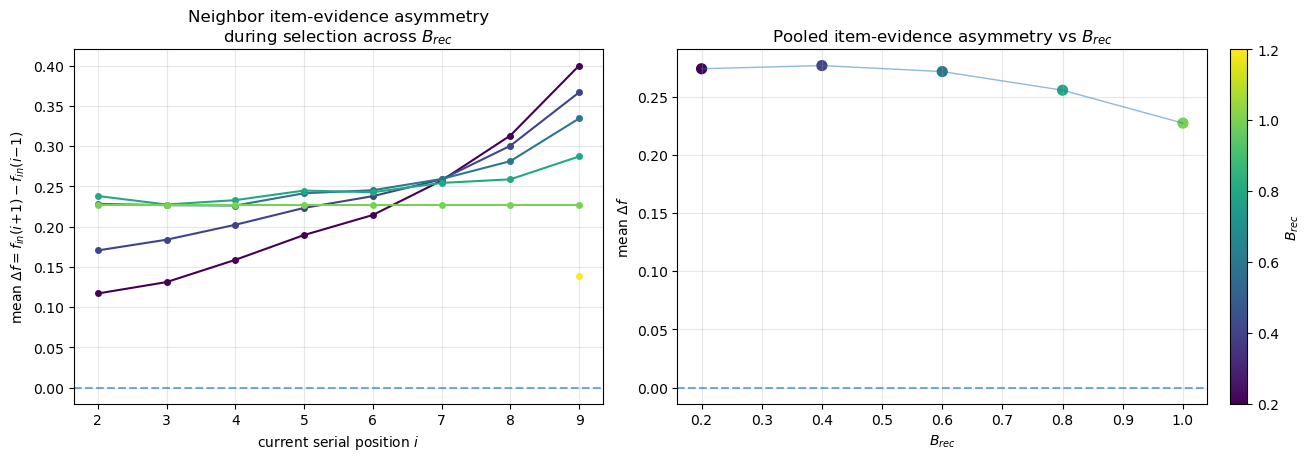

In [10]:
plot_item_evidence_asymmetry_paired(sweep_B_rec, B_rec_grid, param_name=r"$B_{rec}$")

---
## $\gamma_{fc}$

### Cosine similarity $\cos(c, c_{in})$ after update

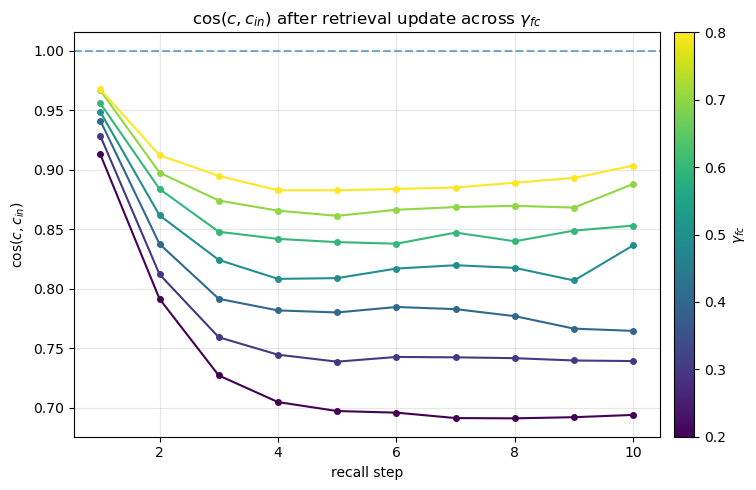

In [11]:
plot_cosine_similarity_sweep(sweep_gamma_fc, gamma_fc_grid, param_name=r"$\gamma_{fc}$")

### Mean evidence $f_{in}(i)$ by serial position

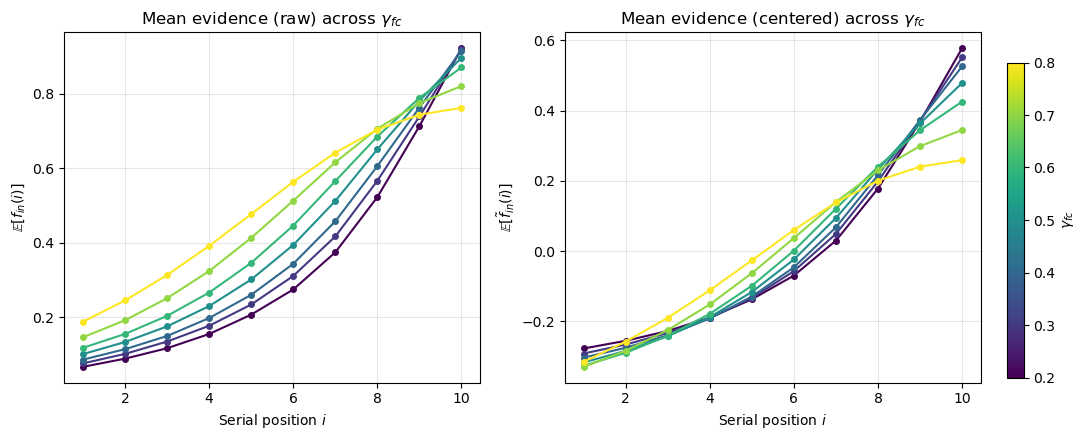

In [12]:
plot_mean_evidence_by_pos(sweep_gamma_fc, gamma_fc_grid, param_name=r"$\gamma_{fc}$")

### Neighbor item-evidence asymmetry during selection

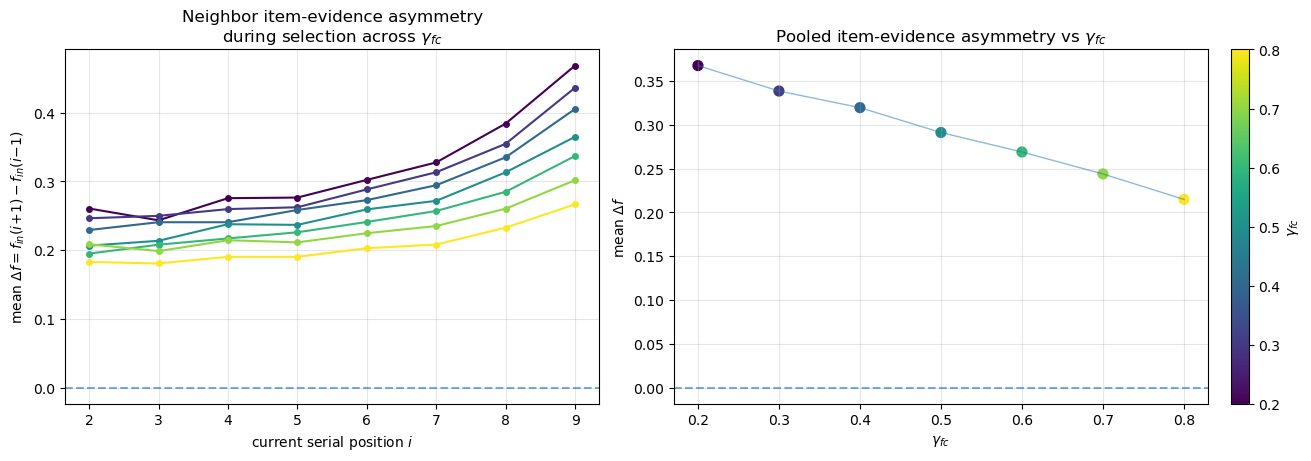

In [13]:
plot_item_evidence_asymmetry_paired(sweep_gamma_fc, gamma_fc_grid, param_name=r"$\gamma_{fc}$")

---
## $\eta$

### Cosine similarity $\cos(c, c_{in})$ after update

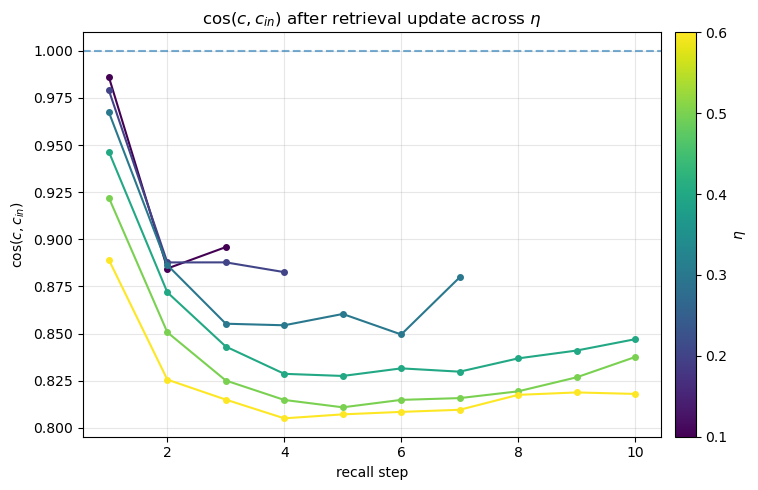

In [14]:
plot_cosine_similarity_sweep(sweep_eta, eta_grid, param_name=r"$\eta$")

### Mean evidence $f_{in}(i)$ by serial position

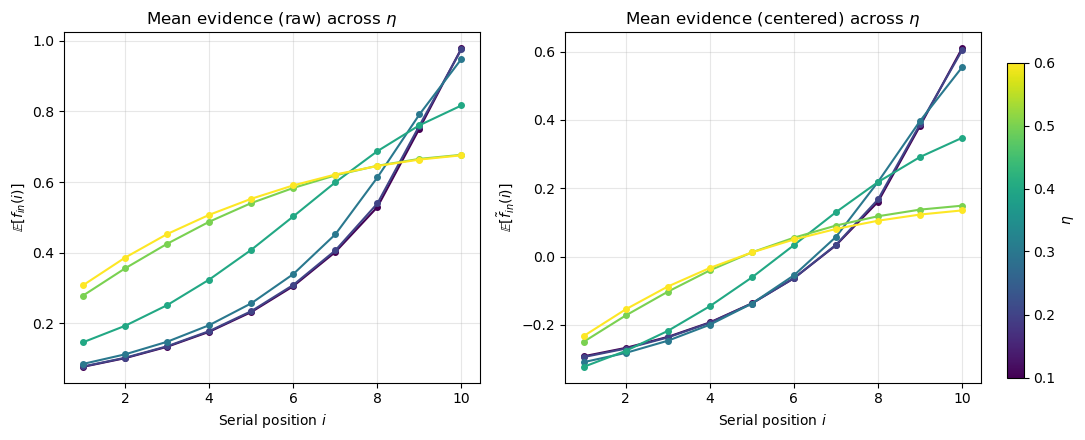

In [15]:
plot_mean_evidence_by_pos(sweep_eta, eta_grid, param_name=r"$\eta$")

### Neighbor item-evidence asymmetry during selection

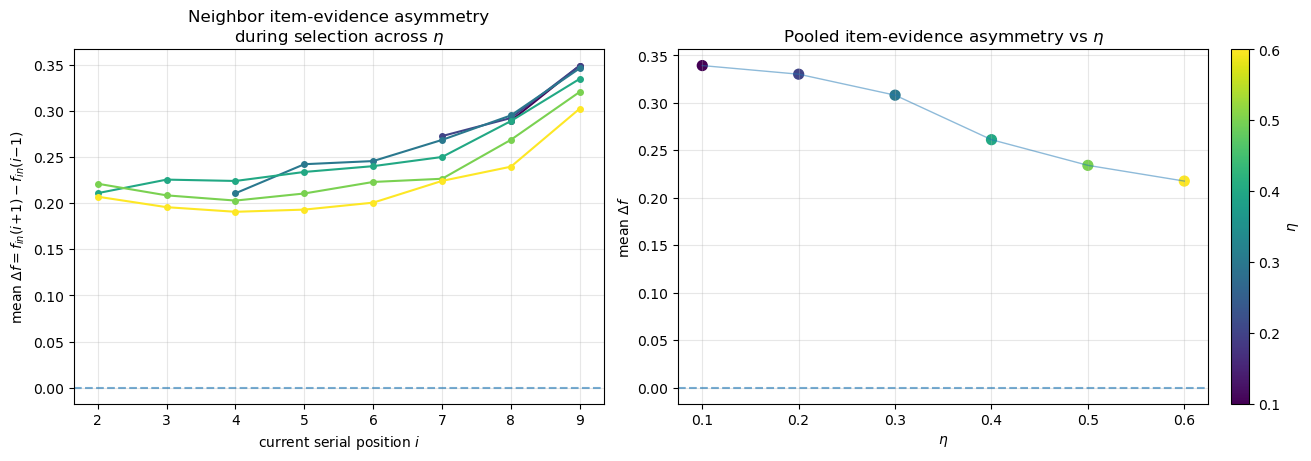

In [16]:
plot_item_evidence_asymmetry_paired(sweep_eta, eta_grid, param_name=r"$\eta$")

---
## $B_{enc}$ scale

### Cosine similarity $\cos(c, c_{in})$ after update

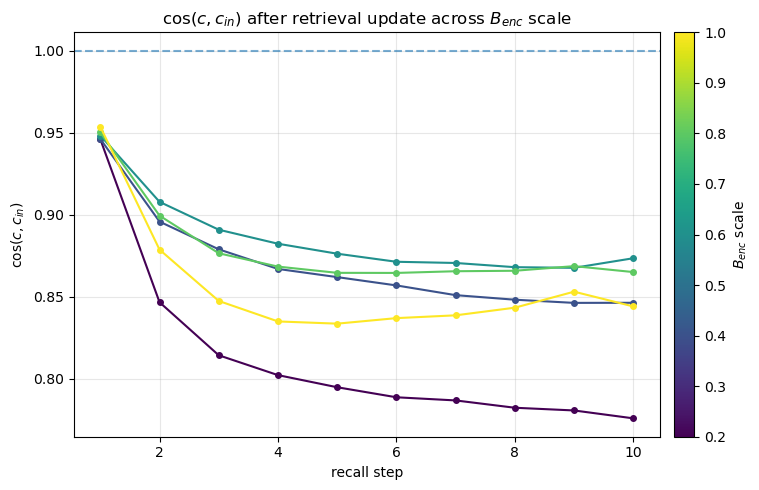

In [17]:
plot_cosine_similarity_sweep(sweep_B_enc_scale, B_encD_scale_grid, param_name=r"$B_{enc}$ scale")

### Mean evidence $f_{in}(i)$ by serial position

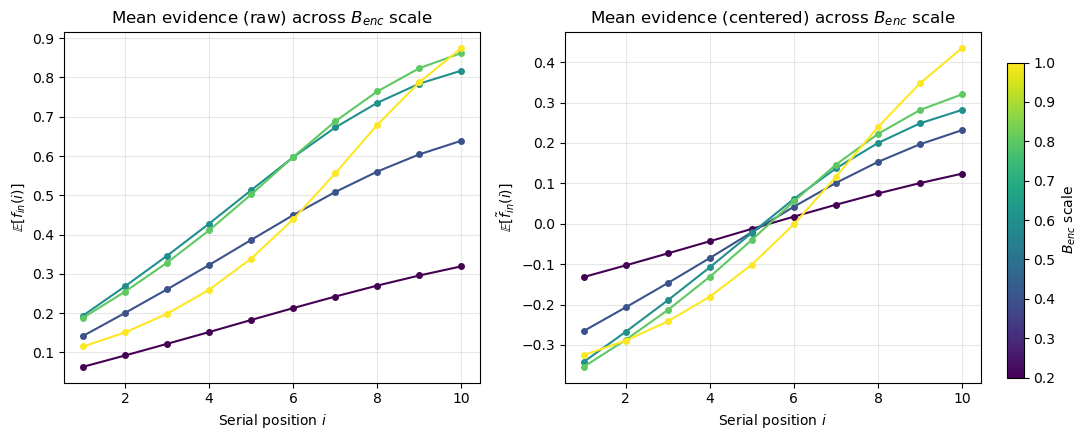

In [18]:
plot_mean_evidence_by_pos(sweep_B_enc_scale, B_encD_scale_grid, param_name=r"$B_{enc}$ scale")

### Neighbor item-evidence asymmetry during selection

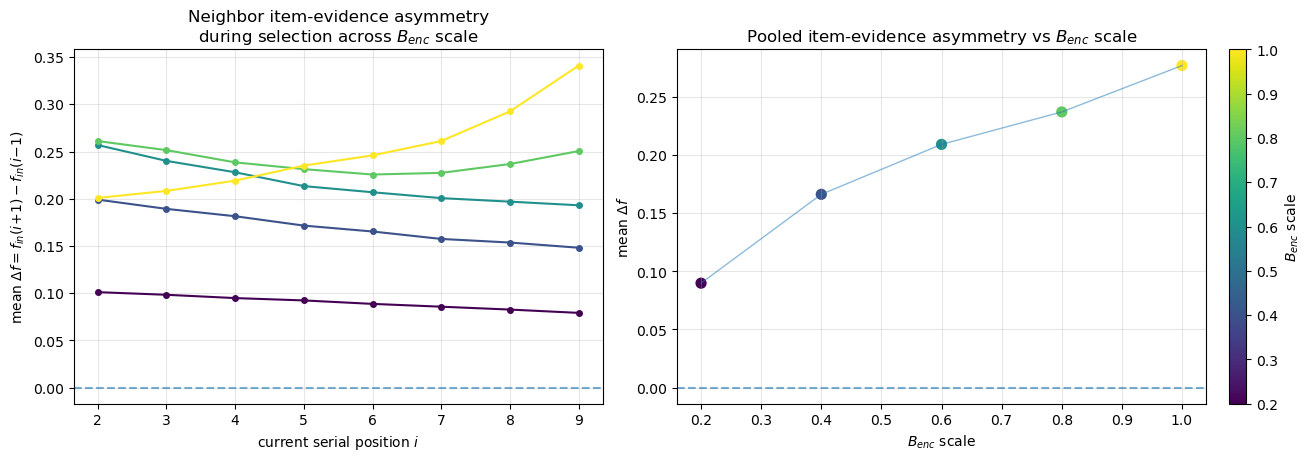

In [19]:
plot_item_evidence_asymmetry_paired(sweep_B_enc_scale, B_encD_scale_grid, param_name=r"$B_{enc}$ scale")

---
## Cross-parameter comparison

Per-step traces ($\cos(c,\hat{c}_{in})$, mean evidence by position)
and pooled item-evidence asymmetry across all four sweeps.

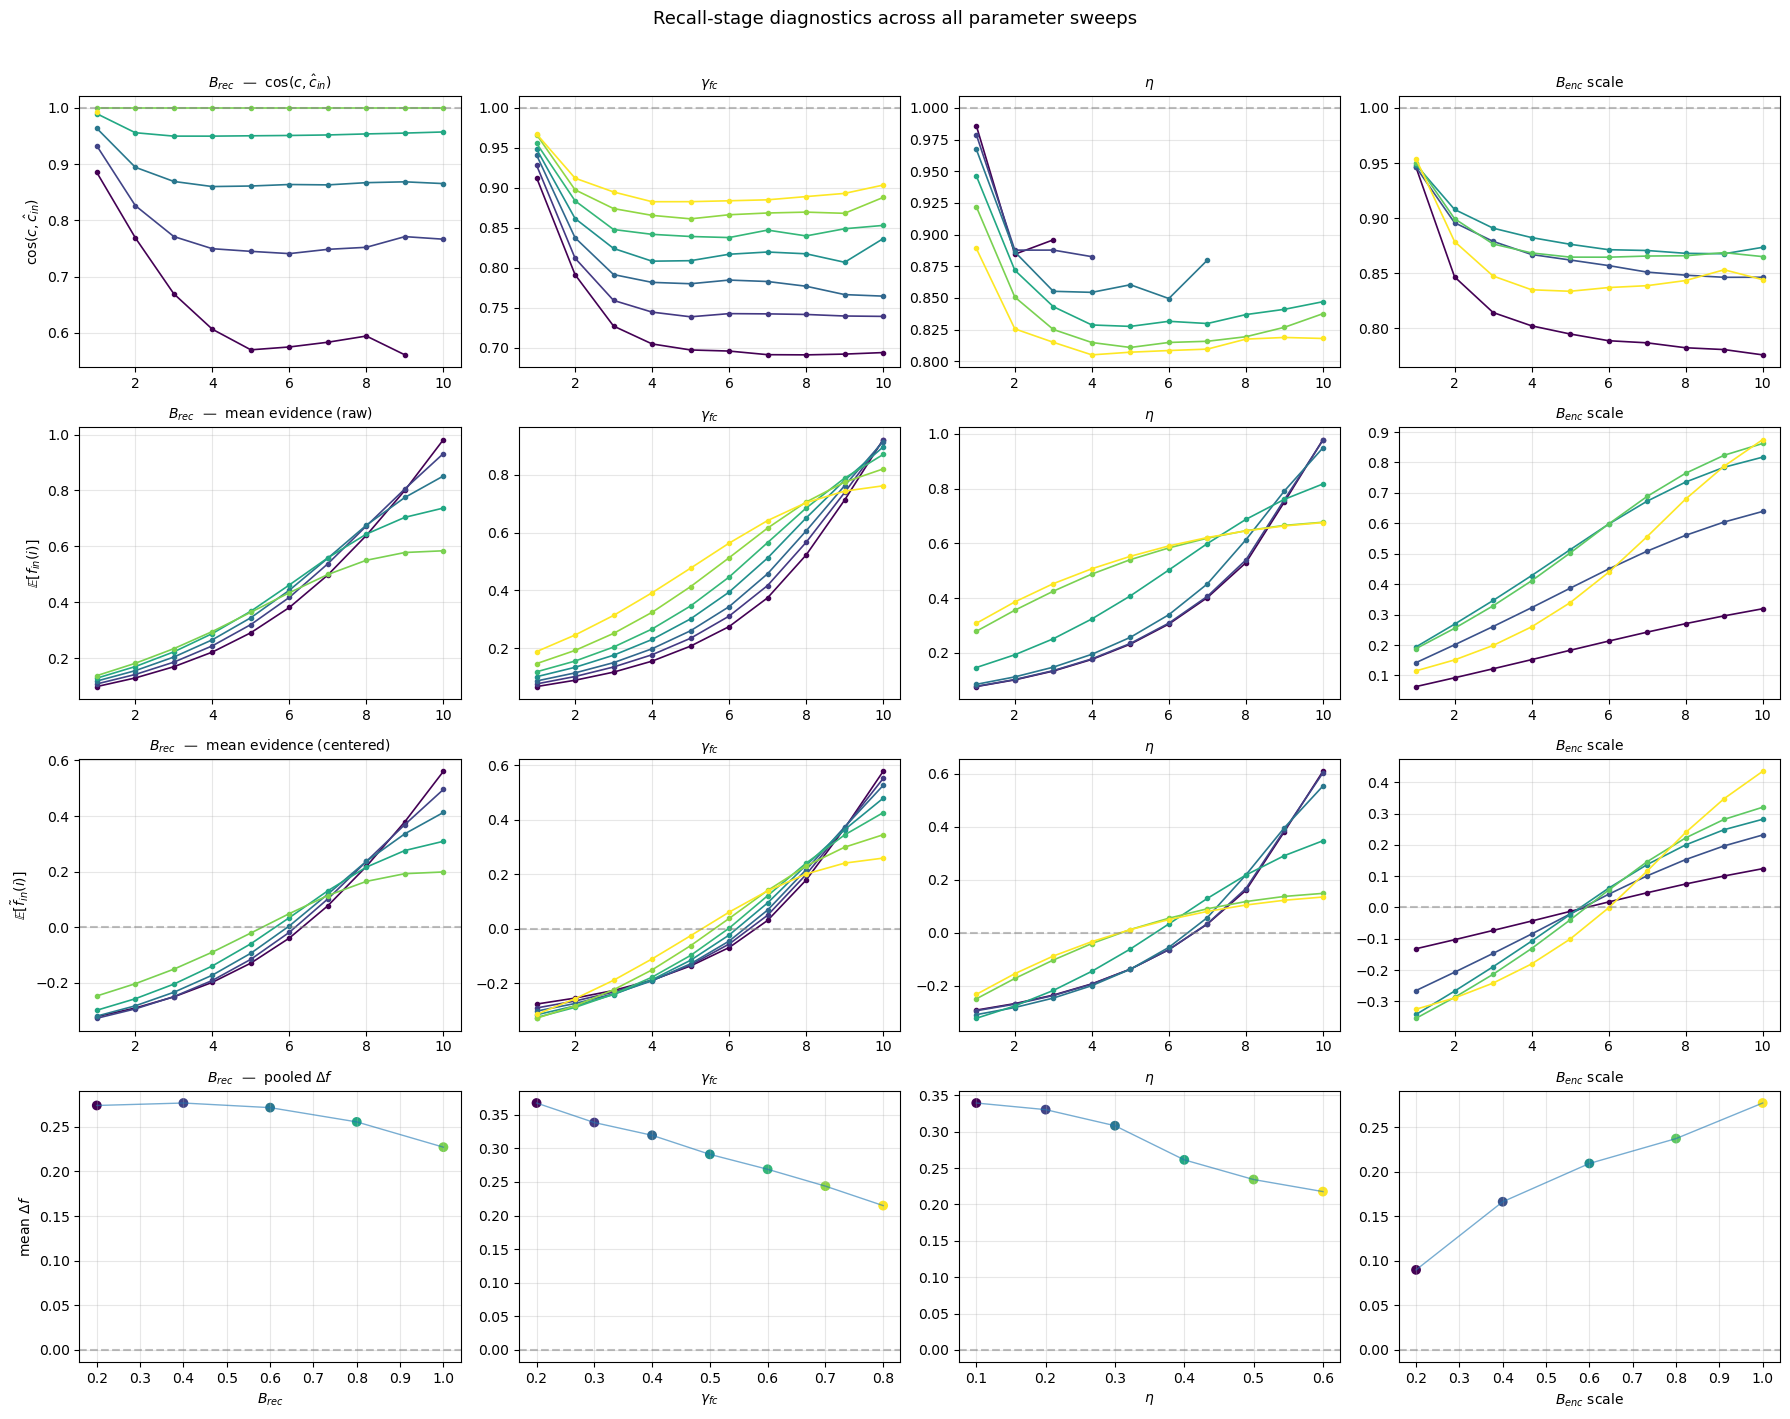

In [22]:
sweeps = [
    (sweep_B_rec,       B_rec_grid,        r"$B_{rec}$"),
    (sweep_gamma_fc,    gamma_fc_grid,      r"$\gamma_{fc}$"),
    (sweep_eta,         eta_grid,           r"$\eta$"),
    (sweep_B_enc_scale, B_encD_scale_grid,  r"$B_{enc}$ scale"),
]

# ── Row 0: cos(c, c_in)  Row 1: mean evidence (raw)  Row 2: mean evidence (centered)  Row 3: pooled Δf ──
fig, axs = plt.subplots(4, 4, figsize=(18, 14), sharex=False)

sp = np.arange(1, N + 1)

for col, (sweep, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(grid)

    # Row 0: cos(c, c_in) per step
    ax = axs[0, col]
    for val, c in zip(grid, colors):
        ts = get_trace_sims(sweep, val)
        x, ca = mean_curve_over_sims(ts, "cos_after")
        if x.size:
            ax.plot(x, ca, color=c, lw=1.2, ms=3, marker="o")
    ax.axhline(1, ls="--", color="gray", alpha=0.5)
    if col == 0:
        ax.set_ylabel(r"$\cos(c, \hat{c}_{in})$")
    ax.grid(alpha=0.3)

    # Row 1: mean evidence (raw)
    ax = axs[1, col]
    for val, c in zip(grid, colors):
        ts = get_trace_sims(sweep, val)
        ax.plot(sp, mean_vector_over_sims(ts, "f_mean_by_pos"),
                color=c, lw=1.2, ms=3, marker="o")
    if col == 0:
        ax.set_ylabel(r"$\mathbb{E}[f_{in}(i)]$")
    ax.grid(alpha=0.3)

    # Row 2: mean evidence (centered)
    ax = axs[2, col]
    for val, c in zip(grid, colors):
        ts = get_trace_sims(sweep, val)
        ax.plot(sp, mean_vector_over_sims(ts, "f_mean_centered_by_pos"),
                color=c, lw=1.2, ms=3, marker="o")
    ax.axhline(0, ls="--", color="gray", alpha=0.5)
    if col == 0:
        ax.set_ylabel(r"$\mathbb{E}[\tilde{f}_{in}(i)]$")
    ax.grid(alpha=0.3)

    # Row 3: pooled Δf (item-evidence asymmetry)
    ax = axs[3, col]
    adv = np.array([
        np.mean(_get_sweep_entry(sweep, v)["item_evidence_diag"]["deltas_all"])
        if _get_sweep_entry(sweep, v)["item_evidence_diag"]["deltas_all"] else np.nan
        for v in grid], dtype=float)
    line_with_colored_points(ax, grid, adv, colors)
    ax.axhline(0, ls="--", color="gray", alpha=0.5)
    if col == 0:
        ax.set_ylabel(r"mean $\Delta f$")
    ax.set_xlabel(label)
    ax.grid(alpha=0.3)

    if col == 0:
        axs[0, col].set_title(label + r"  —  $\cos(c,\hat{c}_{in})$", fontsize=10)
        axs[1, col].set_title(label + r"  —  mean evidence (raw)", fontsize=10)
        axs[2, col].set_title(label + r"  —  mean evidence (centered)", fontsize=10)
        axs[3, col].set_title(label + r"  —  pooled $\Delta f$", fontsize=10)
    else:
        for row in range(4):
            axs[row, col].set_title(label, fontsize=10)

fig.suptitle("Recall-stage diagnostics across all parameter sweeps", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()